# Particle stack generator

This notebook simulates a stack of 2D particle images from a PDB/mmCIF structure. All of the parameters that control the simulation live in [`particle_stack.toml`](./particle_stack.toml), loaded by the second cell via `load_config("particle_stack.toml")` — **edit that file, not this notebook**, to change what gets generated.

## Editing `particle_stack.toml`

The TOML file is grouped into tables for readability; `load_config` flattens them, so the table names (`[potential]`, `[microscope]`, etc.) are just organization and don't need to match `ParticleStackConfig` field names directly:

| Table | Controls |
|---|---|
| `[potential]` | PDB code / assembly, box size (`num_pixels`), pixel size |
| `[microscope]` | Accelerating voltage, dose, spherical aberration (`cs`), amplitude contrast (`alpha`) |
| `[envelopes]` | Envelope functions (B-factor, Cs/Cc envelopes, voltage spread) |
| `[sampling]` | Defocus (single number or `[low, high]` range) and max in-plane shift particles are drawn from |
| `[dataset]` | Number of particles to generate (`n_particles`) |
| `[models]` | Which physics models to use (scattering, aberration, noise, ice, detector) |
| `[ice]` | Ice thickness and, for `ice_model = "gd"`, the cache directory to draw from |
| `[compute]` | Device (`cuda:0`, `cpu`, ...) and batch size |

A commented-out line means that field is left at its `ParticleStackConfig` default — see [`configs/particle.toml`](../../configs/particle.toml) for the full set of available fields and their defaults, and [`src/specter/config.py`](../../src/specter/config.py) for authoritative types/units. Common edits:

- **Change the structure**: set `pdb_code` under `[potential]` to a different PDB ID.
- **Generate more/fewer particles**: change `n_particles` under `[dataset]`.
- **Use a different GPU or CPU**: change `device` under `[compute]` (e.g. `"cuda:0"`, `"cuda:1"`, `"cpu"`).
- **Widen/narrow the defocus range**: adjust `defocus` under `[sampling]` — a single number (Å) for constant defocus, or `[low, high]` (e.g. `[5000.0, 15000.0]`) to sample uniformly per particle. The same scalar-or-pair convention applies to `dose` and `coincidence_radius`.

After editing the TOML file, re-run the notebook from the top (or just re-run the `load_config(...)` cell and everything below it) to pick up the new values.


In [ ]:
import logging

import matplotlib.pyplot as plt
import torch

import specter
from specter import rotations
from specter.config import load_config, parse_scalar_or_range
from specter.fft import fft2
from specter.image import normalize_particles
from specter.imagegenerator import ImageGenerator
from specter.memory import resolve_batchsize
from specter.pdb import PDB
from specter.plots import plot3d
from specter.potential import PotentialBuilder
from specter.arrays import radial_profile_2d
from specter.progress import track
from specter.ice import IceBank, RandomIcemaker

%load_ext autoreload
%autoreload 2

In [2]:
config = load_config("particle_stack.toml")

In [3]:
specter.set_verbosity(logging.INFO)

## Create 3D scattering potential

In [4]:
# fetch pdb file
pdb = PDB(config.pdb_code, assembly=config.assembly, savefolder=config.pdb_savefolder)

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: /mnt/cbis/home/e0788253/czii/specter/pdb-data/6bdf-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [5]:
atom_species = PDB.get_atom_species(pdb.filepath, verbose=False)

pb = PotentialBuilder(
    config.num_pixels,
    config.pixel_size,
    pdb.atomic_numbers,
    parameterization="shtyrov",
    atom_species=atom_species,
)

/tmp/ipykernel_3980191/121439762.py:1: RuntimeWarning: CLIBD_MON is not set; falling back to gemmi's built-in chemical-component definitions. Bond topology for standard residues is still derived from the file itself, but hydrogens cannot be added, so H-containing Shtyrov species (e.g. 'O(HH)', 'C(HHHC)') will not be resolved.
  atom_species = PDB.get_atom_species(pdb.filepath, verbose=False)


/mnt/cbis/home/e0788253/czii/specter/src/specter/potential.py:984: UserWarning: 15722 atom(s) had no matching Shtyrov species (elements: ['C', 'N', 'O', 'S']); falling back to gemmi's built-in Peng et al. scattering factors for those atoms.
  self._get_3d_shtyrov_species_potentials()


/mnt/cbis/home/e0788253/czii/specter/src/specter/potential.py:1238: UserWarning: 15722 atom(s) had no matching Shtyrov species (elements: ['C', 'N', 'O', 'S']); falling back to gemmi's built-in Peng et al. scattering factors for those atoms.
  a_coefs, b_coefs = self._get_analytic_atom_coefficients()


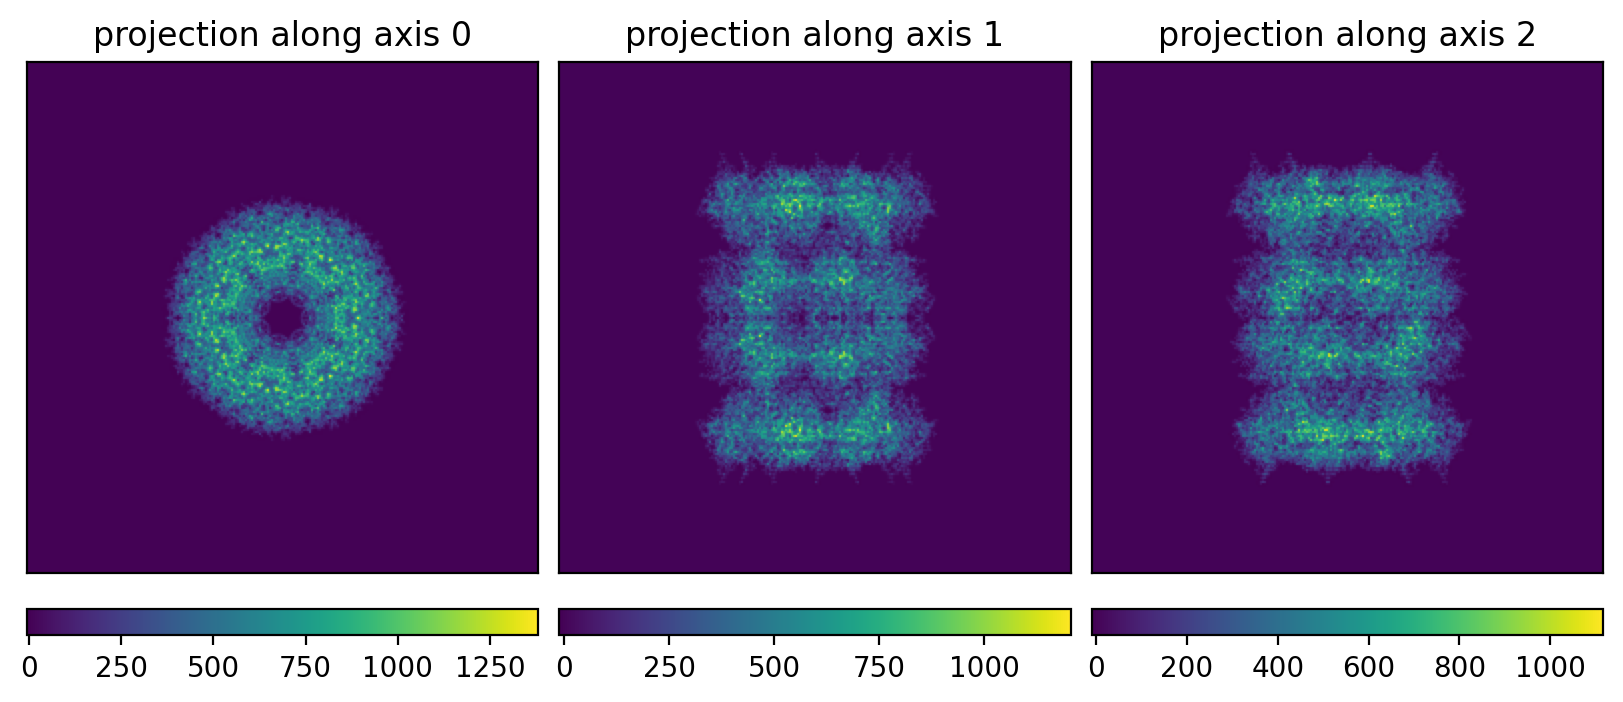

In [6]:
with torch.no_grad():
    V = pb(pdb.coordinates, method="analytic").clone()

plot3d(V)

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [ ]:
# Derived values not directly in ParticleStackConfig
Cs = config.cs * 1e7  # mm -> Å
dose_low, _ = parse_scalar_or_range(config.dose)
num_frames = config.num_frames if config.num_frames is not None else int(dose_low)

In [8]:
# random quaternions
quaternions = rotations.random_quaternion(config.n_particles)
quaternions.shape

torch.Size([20, 4])

In [ ]:
# random defocus
defocus_low, defocus_high = parse_scalar_or_range(config.defocus)
defocus_A = torch.rand(config.n_particles) * (defocus_high - defocus_low) + defocus_low

# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * config.n_particles),
    "dfu": defocus_A,
}

In [10]:
# random shift. set to 0 for no shifts
rlnOriginXAngst = 2 * (torch.rand(config.n_particles) - 0.5) * config.shift
rlnOriginYAngst = 2 * (torch.rand(config.n_particles) - 0.5) * config.shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([20, 2])

In [11]:
device = config.device  # choose cpu if you run out of cuda memory.

In [12]:
# Build the icemaker once — move to GPU before generating
ice_model = None if config.ice_model == "none" else config.ice_model
bank = None
if ice_model == "random":
    n_ice = min(config.num_pixels, int(256 / config.pixel_size))
    bank = RandomIcemaker(dx=config.pixel_size, n=n_ice)
elif ice_model == "gd":
    bank = IceBank(cache_dir=config.ice_cache_dir)
if bank is not None:
    bank = bank.to(device)

In [ ]:
# Coincidence radius in angstroms.
# Higher values suppress lower spatial frequencies.
# Set to 0 to recover default Poisson behaviour.
coincidence_radius, _ = parse_scalar_or_range(config.coincidence_radius)

crowd_min_distance = (
    config.crowd_min_distance
    if config.crowd_min_distance is not None
    else pdb.max_diameter
)

detector_model = None if config.detector_model == "none" else config.detector_model

model = ImageGenerator(
    V,
    config.pixel_size,
    quaternions,
    translations,
    ctf_params,
    config.voltage,
    dose_low,
    ice_model=config.ice_model,
    ice_thickness=config.ice_thickness,
    scattering_model=config.scattering_model,
    aberration_model=config.aberration_model,
    noise_model=config.noise_model,
    klim=None,
    ews_curvature_sign="positive",
    alpha=config.alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=config.crowd_max_distance_z,
    pad_fft=config.pad_fft,
    detector_model=detector_model,
    verbose=False,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
    icemaker=bank,
    bfactor=config.bfactor,
).to(device)

In [14]:
# config.batchsize may be an int or "auto"; resolve_batchsize turns "auto"
# into the largest batch that fits the memory free on `device` right now.
batchsize = resolve_batchsize(
    config.batchsize,
    config.num_pixels,
    model.nz,
    model.pad_nxy,
    device,
    n_particles=config.n_particles,
)

idx = torch.arange(config.n_particles)
images = []
with torch.no_grad():
    for i in track(
        range(0, config.n_particles, batchsize), description="Generating images"
    ):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Generating images:   0%|          | 0/4 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/8 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/9 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/9 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/5 [00:00<?, ?it/s]

...

Applying coincidence loss:   0%|          | 0/20 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/20 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/20 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/20 [00:00<?, ?it/s]

torch.Size([20, 256, 256])

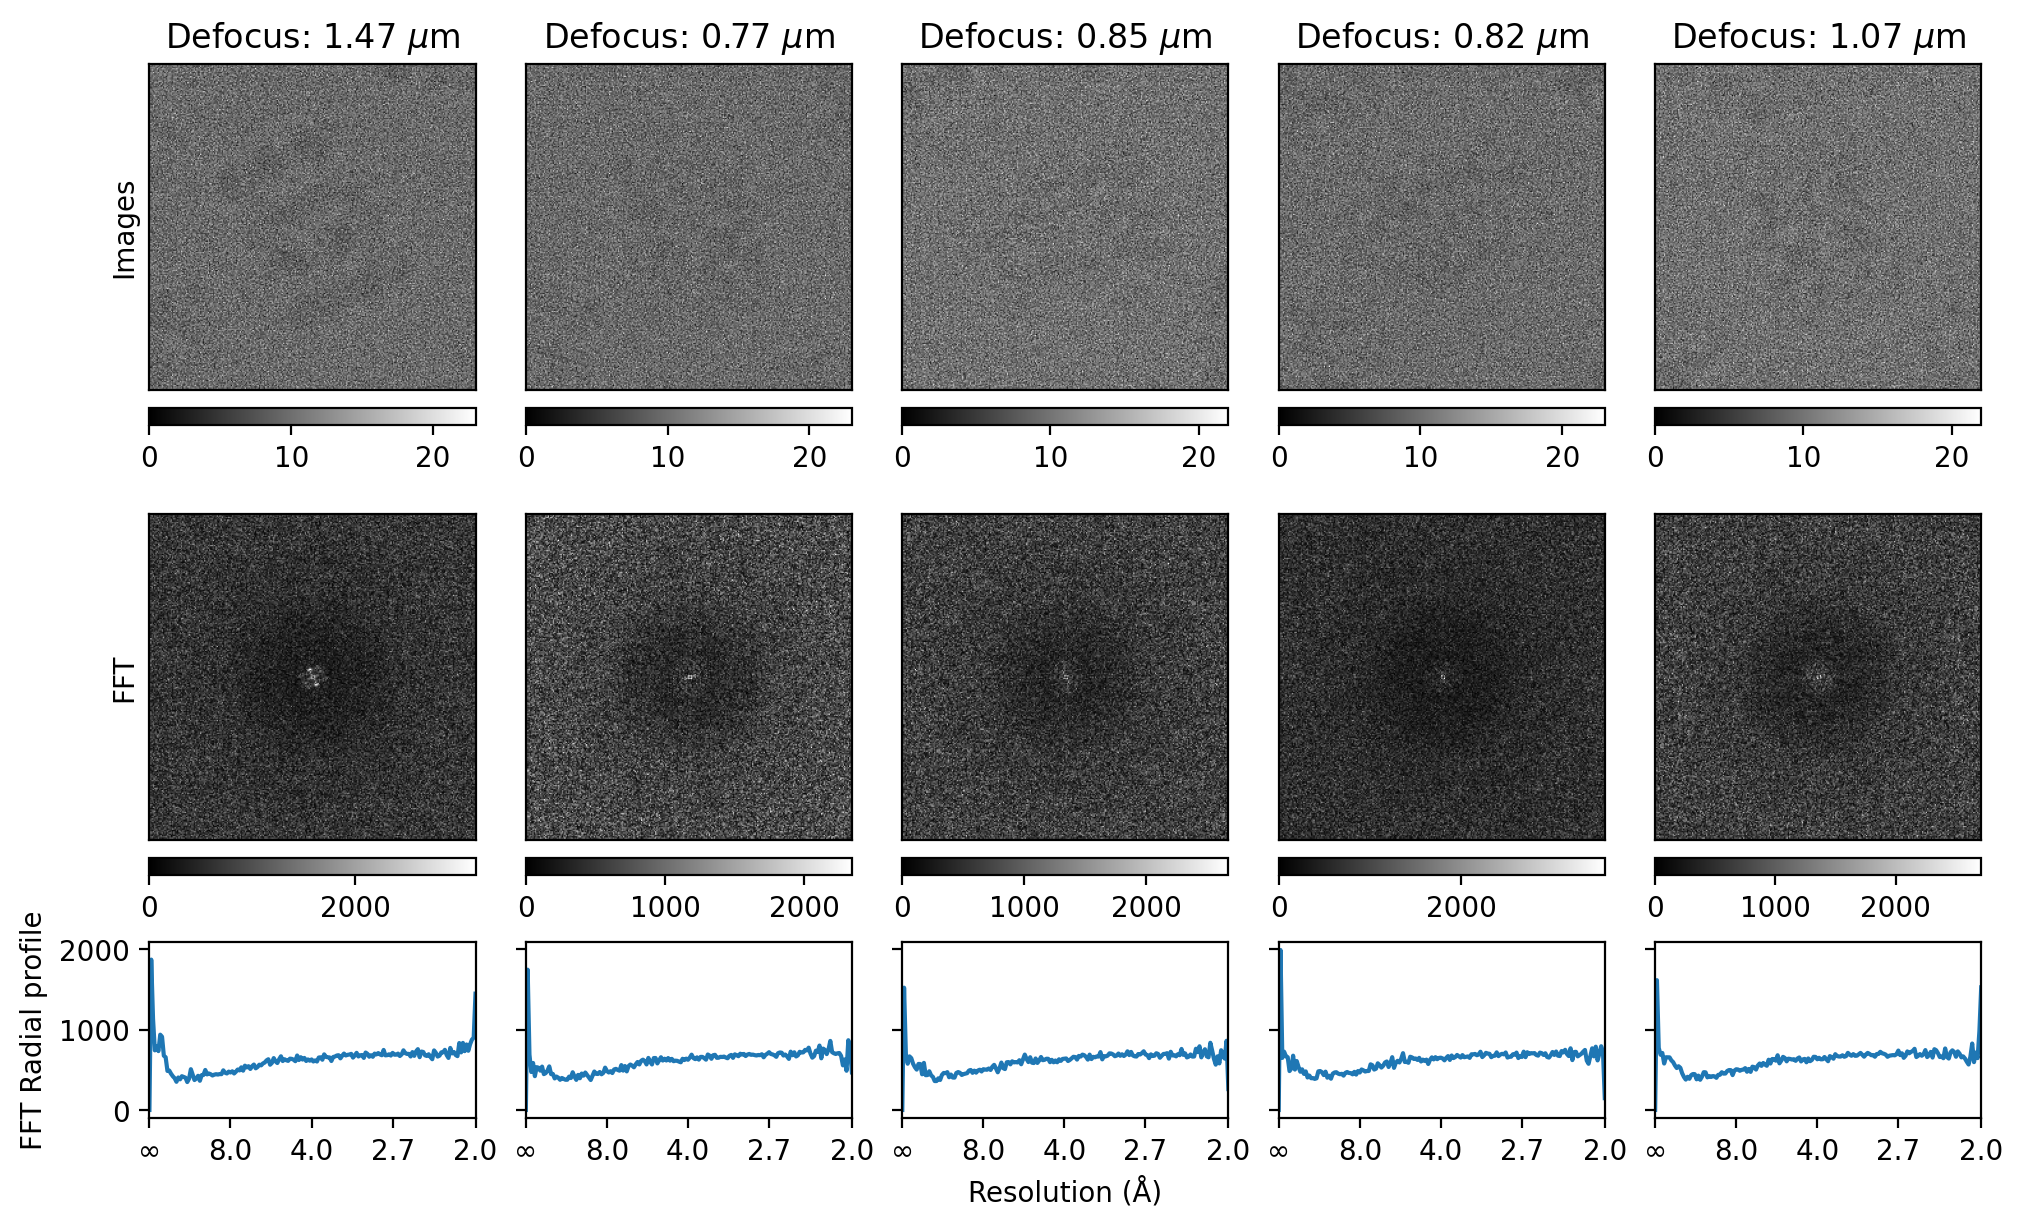

In [15]:
fig, axes = plt.subplots(
    3,
    5,
    dpi=200,
    constrained_layout=True,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 2, 1]},
)
# after creating the axes, share y across the last row
for ax in axes[2, 1:]:
    ax.sharey(axes[2, 0])
    plt.setp(ax.get_yticklabels(), visible=False)

for i in range(5):
    ax = axes[0, i]
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[1, i]
    im = ax.imshow(
        torch.abs(fft2(images[i] - torch.mean(images[i]), shift=True)),
        cmap="grey",
        # vmax=5000,
    )
    ax.set(xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[2, i]
    profile = radial_profile_2d(
        torch.abs(fft2(images[i] - torch.mean(images[i]), shift=True))
    )
    n = len(profile)
    ax.plot(profile.numpy() if hasattr(profile, "numpy") else profile)

    # X ticks: 6 ticks from 0 (inf) to n-1 (Nyquist)
    tick_positions = [int(j * (n - 1) / 4) for j in range(5)]
    # Spatial frequency in 1/Å: ranges from 0 to 1/(2*dx)
    # Avoid division by zero at position 0 (inf)
    tick_labels = []
    for pos in tick_positions:
        if pos == 0:
            tick_labels.append("∞")
        else:
            freq = (pos / (n - 1)) * (1 / (2 * config.pixel_size))  # 1/Å
            resolution = 1 / freq  # Å
            tick_labels.append(f"{resolution:.1f}")

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(0, n - 1)

axes[0, 0].set(ylabel="Images")
axes[1, 0].set(ylabel="FFT")
axes[2, 0].set(ylabel="FFT Radial profile")
axes[2, 2].set_xlabel("Resolution (Å)")

plt.show()

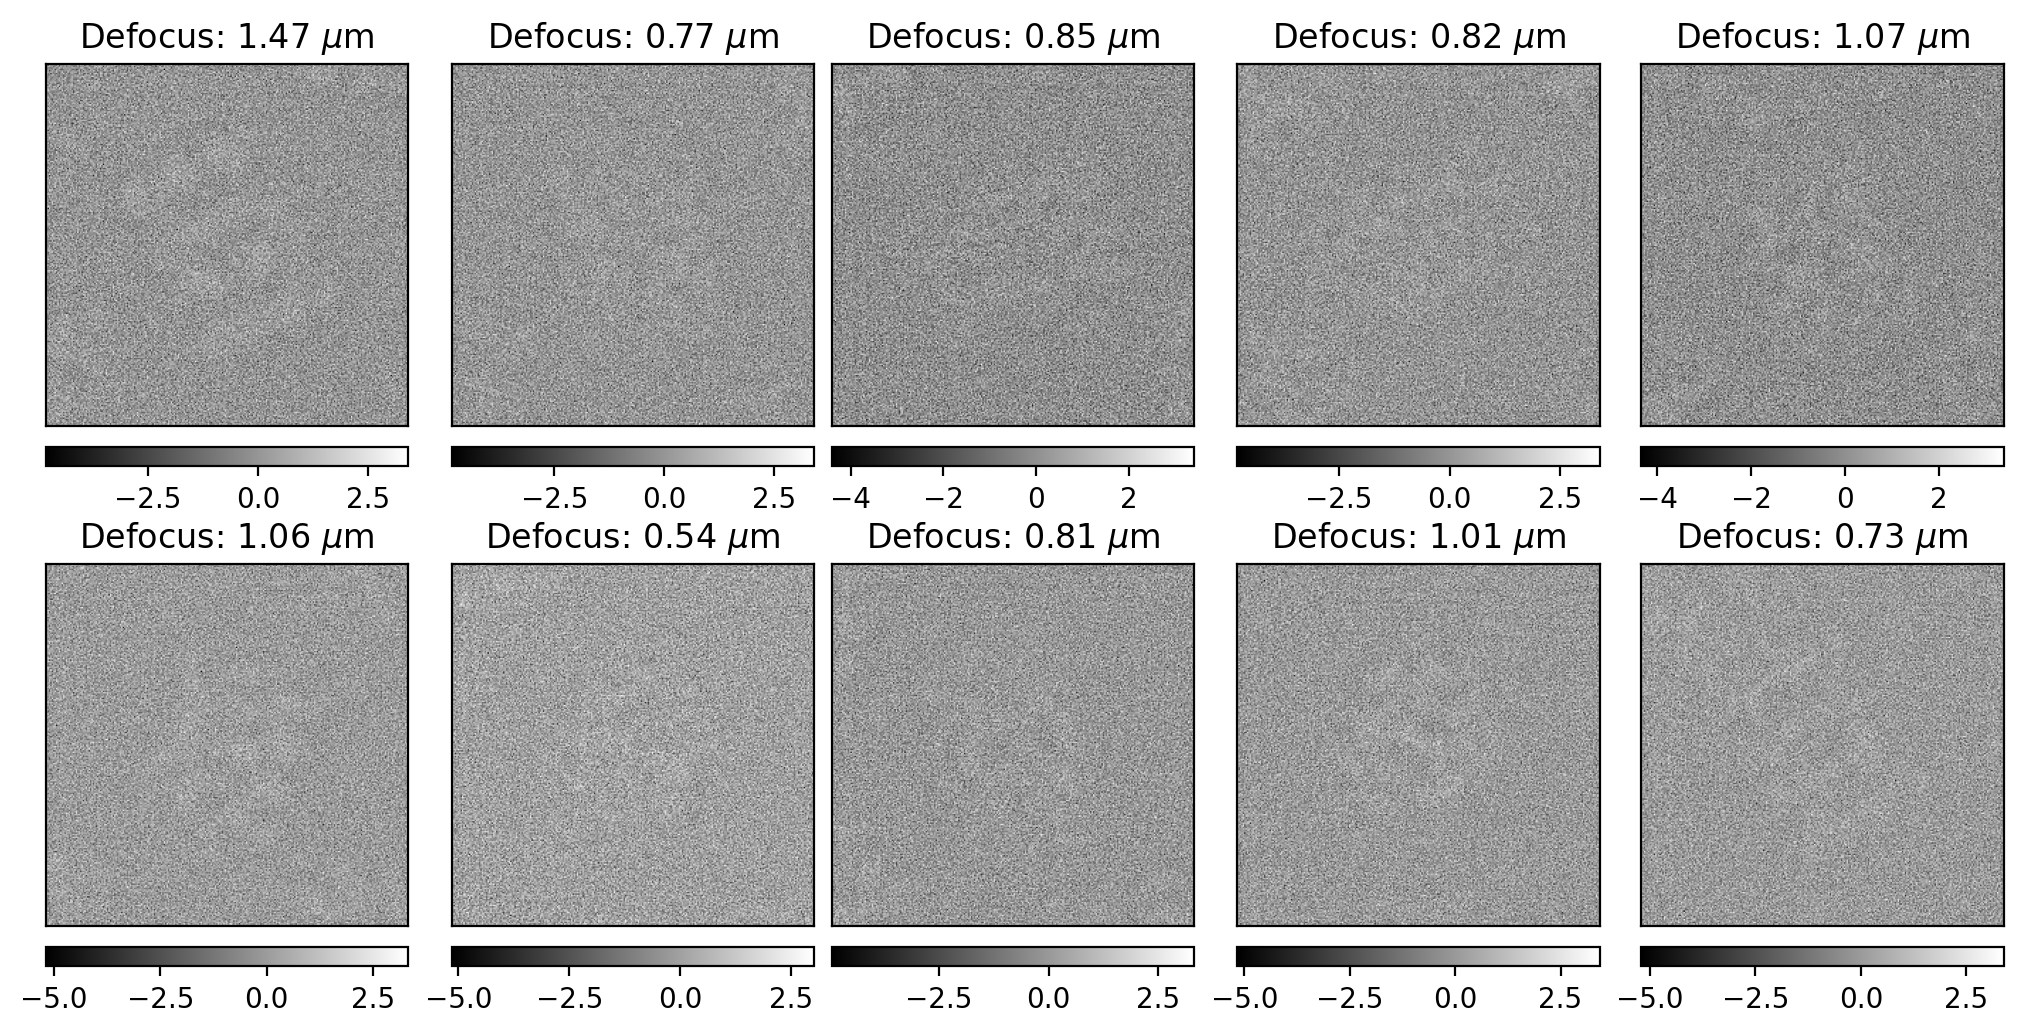

In [16]:
# normalize and flip sign
particles, means, stds = normalize_particles(images)
particles = -particles

fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(particles[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [17]:
# change folder paths for your use.
# from specter.io import create_particle_starfile_from_model
#
# folderpath = "/myfolder/"
# filename = "particles"
#
# # Reads pose, CTF, and physics parameters (bfactor, potential_scale,
# # coincidence_radius, dose_per_angstrom) directly from `model`, so the
# # STAR file always matches what was actually simulated.
# create_particle_starfile_from_model(
#     particles,
#     model,
#     filename=filename,
#     folderpath=folderpath,
# )